In [1]:
# ## System & Device Check  (safe on CUDA / MPS / CPU)
# PyTorch/NVIDIA are already installed & working -> the pip cells above stay
# commented. This cell only *reports* hardware and never raises.
import sys, torch
try:
    import torch_geometric
    _pyg = torch_geometric.__version__
except Exception:
    _pyg = "not installed"

print("=" * 50)
print("System Check")
print("=" * 50)
print(f"Python : {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"PyG    : {_pyg}")

def detect_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = detect_device()
print(f"\nSelected device: {device}")

# Fully-guarded hardware probe (errors here never stop the notebook).
try:
    if device.type == "cuda":
        print(f"  GPU     : {torch.cuda.get_device_name(0)}")
        print(f"  CUDA    : {torch.version.cuda}")
        print(f"  GPU mem : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
        _ = torch.randn(8, 8, device=device)        # smoke test
        print("  \u2705 CUDA tensor test passed")
    elif device.type == "mps":
        _ = torch.randn(8, 8, device=device)
        print("  \u2705 Apple MPS tensor test passed")
    else:
        print("  \u2139\ufe0f  Running on CPU")
except Exception as e:
    print(f"  \u26a0\ufe0f device probe failed ({e}); training will fall back to CPU")


System Check
Python : 3.12.8
PyTorch: 2.5.1+cu121
PyG    : 2.8.0

Selected device: cuda
  GPU     : NVIDIA GeForce RTX 4070 Laptop GPU
  CUDA    : 12.1
  GPU mem : 8.6 GB
  ✅ CUDA tensor test passed


In [2]:
# ==================================================
# HAN Training for RC Element Prediction
# ==================================================

# ## Cell 1: Setup and Imports
import os
import sys
import yaml
import logging
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import torch_geometric
from torch.serialization import add_safe_globals
import warnings
warnings.filterwarnings('ignore')

print(f"📁 Current directory: {os.getcwd()}")

# Add project paths
sys.path.append("..")
sys.path.append("../src")

# Basic logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(name)-8s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S"
)

logger = logging.getLogger("NOTEBOOK")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('default')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

print("✅ Setup complete")

📁 Current directory: c:\other\Mehrnaz\Work\RC-Element-Prediction-GNN\notebooks
✅ Setup complete


In [3]:
# ## Cell 2: Import Project Modules

print("Importing project modules...")

from src.models import build_model
from src.training.trainer import HGTrainer, DeviceManager

print("✅ Modules imported successfully")

Importing project modules...
✅ Modules imported successfully


In [4]:
# ## Cell 3: Load Configuration

print("Loading configurations...")

# Load base config
with open("../configs/base.yaml", "r") as f:
    base_config = yaml.safe_load(f)

# Load HAN config (create if not exists)
han_config_path = "../configs/models/han.yaml"
if os.path.exists(han_config_path):
    with open(han_config_path, "r") as f:
        han_config = yaml.safe_load(f)
else:
    print("⚠️ han.yaml not found, creating default config...")
    han_config = {
        'model': {
            'type': 'han',
            'hidden_channels': 128,
            'num_layers': 3,
            'num_heads': 4,
            'dropout': 0.3,
            'node_types': ['beam', 'column'],
            'output_dim': 2,
            'use_structural_encoding': True,
        },
        'training': {
            'epochs': 100,
            'learning_rate': 0.001,
            'weight_decay': 0.0001,
            'patience': 20,
            'scheduler_factor': 0.5,
            'scheduler_patience': 10,
            'grad_clip': 1.0,
            'k_folds': 5,
            'loss_type': 'huber',
            'huber_delta': 1.0,
            'width_weight': 1.0,
            'height_weight': 1.0,
            'beam_weight': 1.0,
            'column_weight': 1.0,
        },
        'paths': {
            'checkpoints': 'checkpoints/han',
        }
    }
    # Save default config
    os.makedirs("../configs/models", exist_ok=True)
    with open(han_config_path, "w") as f:
        yaml.dump(han_config, f, default_flow_style=False)
    print("✅ Created default han.yaml")

# Merge configs
config = {**base_config, **han_config}

print("\n📋 Configuration Summary:")
print(f"  Model: {config['model']['type']}")
print(f"  Hidden channels: {config['model']['hidden_channels']}")
print(f"  Layers: {config['model']['num_layers']}")
print(f"  Attention heads: {config['model']['num_heads']}")
print(f"  Dropout: {config['model']['dropout']}")
print(f"  Epochs: {config['training']['epochs']}")
print(f"  Learning rate: {config['training']['learning_rate']}")
print(f"  K-Folds: {config['training']['k_folds']}")

Loading configurations...

📋 Configuration Summary:
  Model: han
  Hidden channels: 128
  Layers: 3
  Attention heads: 4
  Dropout: 0.3
  Epochs: 100
  Learning rate: 0.001
  K-Folds: 5


In [5]:
# ## Cell 4: Load Graphs

print("Loading pre-built graphs...")

# Register safe globals for PyG HeteroData
add_safe_globals([
    torch_geometric.data.storage.BaseStorage,
    torch_geometric.data.storage.NodeStorage,
    torch_geometric.data.storage.EdgeStorage,
    torch_geometric.data.HeteroData
])

# Load graphs
graph_path = "../data/graphs/train_graphs.pt"
if not os.path.exists(graph_path):
    raise FileNotFoundError(f"Graph file not found: {graph_path}")

loaded_data = torch.load(graph_path, weights_only=False)

# Handle different formats of saved graphs
if isinstance(loaded_data, list):
    # Check if it's a list of tuples (sample_name, graph)
    if len(loaded_data) > 0 and isinstance(loaded_data[0], tuple):
        print("Detected format: List of (sample_name, graph) tuples")
        sample_names = [item[0] for item in loaded_data]
        graphs = [item[1] for item in loaded_data]
        
        # Attach sample names to graphs if not present
        for i, (name, graph) in enumerate(zip(sample_names, graphs)):
            if not hasattr(graph, 'sample_name'):
                graph.sample_name = name
    else:
        print("Detected format: List of graphs")
        graphs = loaded_data
elif isinstance(loaded_data, dict):
    print("Detected format: Dictionary of graphs")
    graphs = list(loaded_data.values())
else:
    graphs = loaded_data

print(f"\n✅ Loaded {len(graphs)} graphs")

# Helper function to safely get graph attributes
def get_graph_info(graph):
    """Safely extract graph information."""
    info = {
        'sample_name': 'Unknown',
        'node_types': [],
        'edge_types': [],
    }
    
    # Get sample name
    if hasattr(graph, 'sample_name'):
        info['sample_name'] = graph.sample_name
    elif isinstance(graph, dict) and 'sample_name' in graph:
        info['sample_name'] = graph['sample_name']
    
    # Get node types
    if hasattr(graph, 'node_types'):
        info['node_types'] = list(graph.node_types)
    else:
        # Try to infer node types from attributes
        possible_types = ['beam', 'column']
        for nt in possible_types:
            if hasattr(graph, nt):
                node_data = graph[nt] if not isinstance(graph, dict) else graph.get(nt, {})
                if hasattr(node_data, 'x') or (isinstance(node_data, dict) and 'x' in node_data):
                    info['node_types'].append(nt)
    
    # Get edge types
    if hasattr(graph, 'edge_types'):
        info['edge_types'] = list(graph.edge_types)
    elif hasattr(graph, 'edge_index_dict'):
        info['edge_types'] = list(graph.edge_index_dict.keys())
    
    return info

# Analyze dataset
print("\n📊 Dataset Overview:")
print(f"  Total samples: {len(graphs)}")

# Analyze first few graphs
for i, graph in enumerate(graphs[:3]):
    info = get_graph_info(graph)
    print(f"\n  Graph {i+1}: {info['sample_name']}")
    
    # Count nodes per type
    for node_type in info['node_types']:
        try:
            node_data = graph[node_type] if not isinstance(graph, dict) else graph[node_type]
            if hasattr(node_data, 'x'):
                x = node_data.x
            elif isinstance(node_data, dict) and 'x' in node_data:
                x = node_data['x']
            else:
                x = None
            
            if x is not None:
                num_nodes = x.shape[0]
                num_features = x.shape[1] if len(x.shape) > 1 else 1
                
                # Check for labels
                if hasattr(node_data, 'y'):
                    has_labels = node_data.y is not None
                elif isinstance(node_data, dict):
                    has_labels = 'y' in node_data and node_data['y'] is not None
                else:
                    has_labels = False
                
                print(f"    {node_type}: {num_nodes} nodes, {num_features} features, labels: {has_labels}")
        except Exception as e:
            print(f"    {node_type}: Error accessing - {e}")
    
    # Count edges per type
    for edge_type in info['edge_types']:
        try:
            if hasattr(graph, 'edge_index_dict'):
                edge_index = graph.edge_index_dict.get(edge_type)
            elif isinstance(graph, dict) and 'edge_index_dict' in graph:
                edge_index = graph['edge_index_dict'].get(edge_type)
            else:
                edge_index = None
            
            if edge_index is not None:
                num_edges = edge_index.shape[1] if hasattr(edge_index, 'shape') else len(edge_index[0])
                if num_edges > 0:
                    print(f"    {edge_type}: {num_edges} edges")
        except Exception as e:
            print(f"    {edge_type}: Error accessing - {e}")

# Overall statistics (robust version)
total_beams = 0
total_columns = 0
total_edges = 0

for graph in graphs:
    info = get_graph_info(graph)
    
    # Count beam nodes
    if 'beam' in info['node_types']:
        try:
            node_data = graph['beam'] if not isinstance(graph, dict) else graph['beam']
            x = node_data.x if hasattr(node_data, 'x') else node_data.get('x')
            if x is not None:
                total_beams += x.shape[0]
        except:
            pass
    
    # Count column nodes
    if 'column' in info['node_types']:
        try:
            node_data = graph['column'] if not isinstance(graph, dict) else graph['column']
            x = node_data.x if hasattr(node_data, 'x') else node_data.get('x')
            if x is not None:
                total_columns += x.shape[0]
        except:
            pass
    
    # Count edges
    for edge_type in info['edge_types']:
        try:
            if hasattr(graph, 'edge_index_dict'):
                edge_index = graph.edge_index_dict.get(edge_type)
            elif isinstance(graph, dict) and 'edge_index_dict' in graph:
                edge_index = graph['edge_index_dict'].get(edge_type)
            else:
                edge_index = None
            
            if edge_index is not None:
                total_edges += edge_index.shape[1] if hasattr(edge_index, 'shape') else len(edge_index[0])
        except:
            pass

print(f"\n📈 Total Statistics:")
print(f"  Total beams: {total_beams}")
print(f"  Total columns: {total_columns}")
print(f"  Total nodes: {total_beams + total_columns}")
print(f"  Total edges: {total_edges}")
print(f"  Avg nodes/graph: {(total_beams + total_columns) / len(graphs):.1f}" if len(graphs) > 0 else "  No graphs loaded")
print(f"  Avg edges/graph: {total_edges / len(graphs):.1f}" if len(graphs) > 0 else "  No graphs loaded")

# Validate graphs for training
print("\n🔍 Validating graphs for training...")
valid_graphs = []
invalid_count = 0

for i, graph in enumerate(graphs):
    info = get_graph_info(graph)
    is_valid = True
    issues = []
    
    # Check required node types
    if 'beam' not in info['node_types']:
        issues.append("Missing 'beam' node type")
        is_valid = False
    if 'column' not in info['node_types']:
        issues.append("Missing 'column' node type")
        is_valid = False
    
    # Check features
    for node_type in info['node_types']:
        try:
            node_data = graph[node_type] if not isinstance(graph, dict) else graph[node_type]
            x = node_data.x if hasattr(node_data, 'x') else node_data.get('x')
            if x is None or x.shape[0] == 0:
                issues.append(f"No features for {node_type}")
                is_valid = False
        except:
            issues.append(f"Cannot access {node_type} features")
            is_valid = False
    
    # Check edges
    if len(info['edge_types']) == 0:
        issues.append("No edge types found")
        is_valid = False
    
    if is_valid:
        valid_graphs.append(graph)
    else:
        invalid_count += 1
        if i < 3:  # Only print first few invalid graphs
            print(f"  ⚠️ Graph {i+1} ({info['sample_name']}): {', '.join(issues)}")

# Update graphs list
if invalid_count > 0:
    print(f"\n  ⚠️ Found {invalid_count} invalid graphs (removing from dataset)")
    graphs = valid_graphs
    print(f"  ✅ Using {len(graphs)} valid graphs for training")
else:
    print(f"  ✅ All {len(graphs)} graphs are valid for training")

Loading pre-built graphs...
Detected format: List of (sample_name, graph) tuples

✅ Loaded 254 graphs

📊 Dataset Overview:
  Total samples: 254

  Graph 1: sample_1
    beam: 301 nodes, 41 features, labels: True
    column: 103 nodes, 41 features, labels: True
    ('beam', 'to', 'beam'): 1058 edges
    ('column', 'to', 'column'): 174 edges
    ('beam', 'to', 'column'): 641 edges
    ('column', 'to', 'beam'): 641 edges

  Graph 2: sample_10
    beam: 176 nodes, 41 features, labels: True
    column: 96 nodes, 41 features, labels: True
    ('beam', 'to', 'beam'): 692 edges
    ('column', 'to', 'column'): 162 edges
    ('beam', 'to', 'column'): 546 edges
    ('column', 'to', 'beam'): 546 edges

  Graph 3: sample_100
    beam: 205 nodes, 41 features, labels: True
    column: 109 nodes, 41 features, labels: True
    ('beam', 'to', 'beam'): 652 edges
    ('column', 'to', 'column'): 188 edges
    ('beam', 'to', 'column'): 594 edges
    ('column', 'to', 'beam'): 594 edges

📈 Total Statistics:
 

In [6]:
# ## SWEEP — all (PE x isolated) combinations (this notebook is sweep-only)
# Per combo: (1) k-fold CV with per-fold scores, (2) final model saved to
# results/models/<combo>/, (3) test eval with the FULL metric set, (4) error
# breakdown by node group (beam/col x connected/isolated), (5) the worst test
# graphs by error (to spot data bugs / outliers), (6) PER-NODE error records
# (graph + type + isolation kept) saved for analysis.
#
# Metric glossary (all in cm except R2). See trainer._eval_loop / evaluate():
#   per-type MAE/RMSE = pooled over ALL nodes of that type across all test
#       graphs. Width (b) & height (h) are ALSO reported separately.
#       R2 is computed PER DIMENSION then uniform-averaged (== sklearn multioutput
#       default) so the different scales of b and h never get mixed into one ratio.
#   baseline_MAE = naive predictor: per-type TRAIN-pool MEDIAN (b,h) for every test
#       node. This is the bar the HAN must beat; improve_vs_baseline = base - model.
#   weighted_MAE   = error pooled over ALL nodes (each NODE counts equally, so
#                    the more numerous type dominates). == test_overall_mae.
#   unweighted_MAE = simple mean of beam_MAE and col_MAE (each TYPE counts
#                    equally regardless of node count). == test_unweighted_mae.
import itertools, copy, os, json, traceback
import numpy as np, pandas as pd, torch
from src.data_manager.data_processor import PositionalEncoder, IsolatedNodeHandler
from src.models import build_model
from src.training.trainer import Trainer

_loaded = torch.load("../data/graphs/train_graphs.pt", weights_only=False)
raw_graphs = [g for (_, g) in _loaded] if isinstance(_loaded[0], tuple) else list(_loaded)
nG = len(raw_graphs)

has_names = hasattr(raw_graphs[0]["beam"], "feature_names")
pe_modes = ["topological", "geometric", "hybrid"] if has_names else ["topological"]
if not has_names:
    print("⚠️  old-format graphs -> topological PE only. Rebuild with notebook 3.\n")
iso_strategies = ["none", "self_loop", "knn"]
knn_k   = config["data"]["isolated"].get("knn_k", 4)
pe_dim  = config["data"]["pe"].get("dim", 8)
n_folds = max(2, min(config["training"].get("k_folds", 5), 5))
HIT_TOL_CM = 5.0   # "within X cm" hit-rate threshold == |pred-true| <= X

MODELS_DIR = "../results/han/models"; os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs("../results/han", exist_ok=True)
np.random.seed(42); idx = np.random.permutation(nG); cut = int(nG * 0.85)
train_idx, test_idx = idx[:cut], idx[cut:]

def _make_model():
    # model is chosen by config["model"]["type"] (== "han" here)
    # through the shared factory, so HGT and HAN wire up identically.
    return build_model(config)

def _at(mm, k, i):
    v = mm.get(k); return v[i] if (v and 0 <= i < len(v)) else float("nan")

def _g(m, k):  # safe metric getter
    return float(m.get(k, float("nan")))

combos = list(itertools.product(pe_modes, iso_strategies))
print(f"Sweeping {len(combos)} combos | {n_folds}-fold CV + final model each "
      f"(~{len(combos)*(n_folds+1)} trainings).\n")

sweep_rows, sweep_preds, breakdown_rows, persample_rows, pernode_rows = [], {}, [], [], []
for ci, (pe_mode, iso) in enumerate(combos, 1):
    tag = f"{pe_mode}_{iso}"
    print("=" * 72)
    print(f"COMBO {ci}/{len(combos)}  |  PE = {pe_mode}  |  isolated = {iso}"
          + (f" (k={knn_k})" if iso == "knn" else ""))
    print("=" * 72)
    try:
        g_all = [raw_graphs[i].clone() for i in range(nG)]
        IsolatedNodeHandler(strategy=iso, k=knn_k).transform(g_all)   # tags was_isolated
        PositionalEncoder(mode=pe_mode, dim=pe_dim).transform(g_all)
        train_pool_s = [g_all[i] for i in train_idx]
        test_s       = [g_all[i] for i in test_idx]

        cfg = copy.deepcopy(config); cfg["paths"] = {"checkpoints": f"{MODELS_DIR}/{tag}"}

        # (1) cross-validation — log every fold
        tr = Trainer(model=_make_model(), config=cfg, show_progress=True)
        cv = tr.cross_validate(train_pool_s, n_folds=n_folds, shuffle=True, random_state=42)
        print("\n  [CV] per-fold val scores (cm):")
        for fr in cv["fold_results"]:
            be = fr["best_epoch"] - 1; mm = fr["metrics"]
            print(f"    fold {fr['tag'].split('_')[-1]}: "
                  f"overall {_at(mm,'val_overall_mae',be):.3f} | "
                  f"beam {_at(mm,'val_beam_mae',be):.3f} | "
                  f"col {_at(mm,'val_column_mae',be):.3f}")
        print(f"  [CV] mean overall MAE = {cv.get('mean_best_val_overall_mae', float('nan')):.3f}"
              f" +/- {cv.get('std_best_val_overall_mae', 0):.3f} cm")

        # (2) final model on full pool
        tr2 = Trainer(model=_make_model(), config=cfg, show_progress=True)
        tr2.fit_final(train_pool_s, val_frac=0.15)
        out = tr2.evaluate(test_s); m = out["metrics"]

        # (3) predictions + (4) per-group breakdown + (5) per-graph + (6) per-node
        groups = {"beam_conn": [], "beam_iso": [], "col_conn": [], "col_iso": []}
        bt, bp, ct, cp = [], [], [], []
        persample = []
        for g, pred in zip(test_s, out["predictions"]):
            name = getattr(g, "sample_name", "graph")
            gerrs = []
            for nt, tt, pp, gc, gi in [("beam", bt, bp, "beam_conn", "beam_iso"),
                                       ("column", ct, cp, "col_conn", "col_iso")]:
                if nt not in pred or not hasattr(g[nt], "y"):
                    continue
                true = g[nt].y.cpu().numpy(); P = pred[nt]
                tt.append(true); pp.append(P)
                err = np.abs(P - true).mean(axis=1)        # per-node abs error (mean of b,h)
                gerrs.append(err)
                wasiso = getattr(g[nt], "was_isolated", None)
                wi = (wasiso.cpu().numpy().astype(bool)
                      if wasiso is not None else np.zeros(true.shape[0], dtype=bool))
                groups[gi].append(err[wi]); groups[gc].append(err[~wi])

                # (6) one row per node — keep graph membership, type, isolation
                for j in range(true.shape[0]):
                    pernode_rows.append({
                        "combo": tag, "sample": name, "node_type": nt, "node_idx": j,
                        "was_isolated": bool(wi[j]),
                        "true_b": float(true[j, 0]), "true_h": float(true[j, 1]),
                        "pred_b": float(P[j, 0]),    "pred_h": float(P[j, 1]),
                        "abs_err_b": float(abs(P[j, 0] - true[j, 0])),
                        "abs_err_h": float(abs(P[j, 1] - true[j, 1])),
                        "node_mae":  float(err[j]),
                    })
            if gerrs:
                allg = np.concatenate(gerrs)
                persample.append((name, int(allg.size), float(allg.mean())))

        sweep_preds[(pe_mode, iso)] = {
            "beam_true": np.concatenate(bt) if bt else np.empty((0, 2)),
            "beam_pred": np.concatenate(bp) if bp else np.empty((0, 2)),
            "col_true":  np.concatenate(ct) if ct else np.empty((0, 2)),
            "col_pred":  np.concatenate(cp) if cp else np.empty((0, 2))}

        # ---- per-dimension metrics (width vs height), from real-unit predictions ----
        def _reg(true, pred):
            """MAE/RMSE/R2 + hit-rate from (N,2)=[width,height]; R2 per dim, uniform-avg."""
            keys = ["mae","rmse","width_mae","height_mae","width_rmse","height_rmse",
                    "width_r2","height_r2","r2",
                    "within_tol","width_within_tol","height_within_tol"]
            if true.shape[0] == 0:
                return {k: float("nan") for k in keys}
            err = pred - true
            r = {"mae": float(np.abs(err).mean()),
                 "rmse": float(np.sqrt((err ** 2).mean())),
                 # hit-rate = fraction of |error| <= HIT_TOL_CM over ALL b & h entries
                 "within_tol": float((np.abs(err) <= HIT_TOL_CM).mean())}
            for di, nm in enumerate(["width", "height"]):
                e = err[:, di]; y = true[:, di]
                r[f"{nm}_mae"]  = float(np.abs(e).mean())
                r[f"{nm}_rmse"] = float(np.sqrt((e ** 2).mean()))
                r[f"{nm}_within_tol"] = float((np.abs(e) <= HIT_TOL_CM).mean())
                ss_res = float((e ** 2).sum())
                ss_tot = float(((y - y.mean()) ** 2).sum())
                r[f"{nm}_r2"]   = (1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")
            # overall R2 = uniform average of per-dim R2 (avoids mixing b/h scales)
            r["r2"] = float(np.nanmean([r["width_r2"], r["height_r2"]]))
            return r

        BT_ = np.concatenate(bt) if bt else np.empty((0, 2))
        BP_ = np.concatenate(bp) if bp else np.empty((0, 2))
        CT_ = np.concatenate(ct) if ct else np.empty((0, 2))
        CP_ = np.concatenate(cp) if cp else np.empty((0, 2))
        beam_r, col_r = _reg(BT_, BP_), _reg(CT_, CP_)
        all_t = np.concatenate([x for x in (BT_, CT_) if x.shape[0]]) if (bt or ct) else np.empty((0, 2))
        all_p = np.concatenate([x for x in (BP_, CP_) if x.shape[0]]) if (bp or cp) else np.empty((0, 2))
        over_r = _reg(all_t, all_p)

        # ---- naive baseline: predict the per-type TRAIN-pool MEDIAN (b,h) for every
        #      test node. Source = targets g[nt].y of the TRAINING graphs only
        #      (real cm, never the test set). Robust to outliers / standard sizes. ----
        base_pred = {}
        for nt in ("beam", "column"):
            ys = [g[nt].y.cpu().numpy() for g in train_pool_s
                  if nt in g.node_types and hasattr(g[nt], "y") and g[nt].y is not None]
            if ys:
                base_pred[nt] = np.median(np.concatenate(ys), axis=0)
        base_err, base_mae_type = [], {}
        for nt, TT in (("beam", BT_), ("column", CT_)):
            if nt in base_pred and TT.shape[0]:
                e = np.abs(base_pred[nt] - TT).mean(axis=1)
                base_mae_type[nt] = float(e.mean()); base_err.append(e)
        base_weighted = float(np.concatenate(base_err).mean()) if base_err else float("nan")
        print("  [naive baseline | per-type TRAIN median (b,h)] "
              + ", ".join(f"{k}={np.round(v, 1).tolist()}" for k, v in base_pred.items())
              + f"  -> weighted MAE {base_weighted:.3f} cm "
              f"(beam {base_mae_type.get('beam', float('nan')):.3f} / "
              f"col {base_mae_type.get('column', float('nan')):.3f})")

        # per-group breakdown
        def gstat(key):
            a = [x for x in groups[key] if len(x)]
            if not a: return (float("nan"), 0)
            v = np.concatenate(a); return (float(v.mean()), int(v.size))
        bd = {"combo": tag}
        for key in ["beam_conn", "beam_iso", "col_conn", "col_iso"]:
            mae_, n_ = gstat(key); bd[f"{key}_MAE"] = round(mae_, 3); bd[f"{key}_n"] = n_
        breakdown_rows.append(bd)
        print(f"\n  [test error by group, cm]: "
              f"beam_conn {bd['beam_conn_MAE']}(n={bd['beam_conn_n']}) | "
              f"beam_iso {bd['beam_iso_MAE']}(n={bd['beam_iso_n']}) | "
              f"col_conn {bd['col_conn_MAE']}(n={bd['col_conn_n']}) | "
              f"col_iso {bd['col_iso_MAE']}(n={bd['col_iso_n']})")

        # worst test graphs (spot data bugs / outliers)
        persample.sort(key=lambda x: -x[2])
        print("  [worst test graphs by MAE, cm]:")
        for nm, nn, e in persample[:5]:
            print(f"    {nm}: {e:.2f} (n={nn})")
        for nm, nn, e in persample:
            persample_rows.append({"combo": tag, "sample": nm, "n_nodes": nn, "MAE": round(e, 3)})

        # full metric row — weighted vs unweighted now DIFFER (trainer bug fixed)
        beam_mae, col_mae = _g(m, "test_beam_mae"), _g(m, "test_column_mae")
        unw = _g(m, "test_unweighted_mae")
        if np.isnan(unw):
            unw = (beam_mae + col_mae) / 2  # fallback for older trainer
        sweep_rows.append({
            "PE": pe_mode, "isolated": iso, "k": (knn_k if iso == "knn" else "-"),
            "weighted_MAE":   round(over_r["mae"], 3),               # node-pooled (all nodes)
            "unweighted_MAE": round(unw, 3),                         # per-type mean
            "beam_MAE": round(beam_mae, 3),
            "col_MAE":  round(col_mae, 3),
            # --- width vs height split (overall = node-pooled) ---
            "width_MAE":  round(over_r["width_mae"], 3),
            "height_MAE": round(over_r["height_mae"], 3),
            "beam_width_MAE":  round(beam_r["width_mae"], 3),
            "beam_height_MAE": round(beam_r["height_mae"], 3),
            "col_width_MAE":   round(col_r["width_mae"], 3),
            "col_height_MAE":  round(col_r["height_mae"], 3),
            # --- hit-rate: % of b/h predictions with error <= HIT_TOL_CM (default 5 cm) ---
            "pct_within_tol":    round(100 * over_r["within_tol"], 1),
            "beam_within_tol":   round(100 * beam_r["within_tol"], 1),
            "col_within_tol":    round(100 * col_r["within_tol"], 1),
            "width_within_tol":  round(100 * over_r["width_within_tol"], 1),
            "height_within_tol": round(100 * over_r["height_within_tol"], 1),
            # --- RMSE (MSE dropped: it is just RMSE**2 in cm**2) ---
            "overall_RMSE": round(over_r["rmse"], 3),
            "beam_RMSE": round(beam_r["rmse"], 3),
            "col_RMSE":  round(col_r["rmse"], 3),
            # --- R2: per-dimension, uniform-averaged (correct multi-output R2) ---
            "overall_R2": round(over_r["r2"], 3),
            "width_R2":   round(over_r["width_r2"], 3),
            "height_R2":  round(over_r["height_r2"], 3),
            "beam_R2": round(beam_r["r2"], 3),
            "col_R2":  round(col_r["r2"], 3),
            # --- naive median baseline (the bar to beat) ---
            "baseline_MAE":      round(base_weighted, 3),
            "baseline_beam_MAE": round(base_mae_type.get("beam", float("nan")), 3),
            "baseline_col_MAE":  round(base_mae_type.get("column", float("nan")), 3),
            "improve_vs_baseline": round(base_weighted - over_r["mae"], 3),
            # --- CV generalization estimate: mean +/- std across folds ---
            "cv_MAE":     round(cv.get("mean_best_val_overall_mae", float("nan")), 3),
            "cv_MAE_std": round(cv.get("std_best_val_overall_mae", float("nan")), 3),
            "model_dir": f"{MODELS_DIR}/{tag}", "status": "ok"})
        print(f"\n--> COMBO {ci} DONE: weighted MAE {sweep_rows[-1]['weighted_MAE']} | "
              f"unweighted {sweep_rows[-1]['unweighted_MAE']} | "
              f"beam {sweep_rows[-1]['beam_MAE']} | col {sweep_rows[-1]['col_MAE']} cm")
        print(f"    error <= {HIT_TOL_CM:.0f} cm: {sweep_rows[-1]['pct_within_tol']}% overall "
              f"(beam {sweep_rows[-1]['beam_within_tol']}% / col {sweep_rows[-1]['col_within_tol']}%)\n")
    except Exception as e:
        print(f"\n!! COMBO {ci} FAILED: {e}\n"); traceback.print_exc()
        _n = float("nan")
        sweep_rows.append({"PE": pe_mode, "isolated": iso, "k": (knn_k if iso == "knn" else "-"),
            "weighted_MAE": _n, "unweighted_MAE": _n, "beam_MAE": _n, "col_MAE": _n,
            "width_MAE": _n, "height_MAE": _n,
            "beam_width_MAE": _n, "beam_height_MAE": _n,
            "col_width_MAE": _n, "col_height_MAE": _n,
            "pct_within_tol": _n, "beam_within_tol": _n, "col_within_tol": _n,
            "width_within_tol": _n, "height_within_tol": _n,
            "overall_RMSE": _n, "beam_RMSE": _n, "col_RMSE": _n,
            "overall_R2": _n, "width_R2": _n, "height_R2": _n, "beam_R2": _n, "col_R2": _n,
            "baseline_MAE": _n, "baseline_beam_MAE": _n, "baseline_col_MAE": _n,
            "improve_vs_baseline": _n, "cv_MAE": _n, "cv_MAE_std": _n,
            "model_dir": "-", "status": f"ERROR: {e}"})

results_table   = pd.DataFrame(sweep_rows).sort_values("weighted_MAE").reset_index(drop=True)
breakdown_table = pd.DataFrame(breakdown_rows)
persample_table = pd.DataFrame(persample_rows)
pernode_table   = pd.DataFrame(pernode_rows)
results_table.to_csv("../results/han/pe_isolated_sweep.csv", index=False)
breakdown_table.to_csv("../results/han/pe_isolated_error_breakdown.csv", index=False)
persample_table.to_csv("../results/han/pe_isolated_persample_errors.csv", index=False)
pernode_table.to_csv("../results/han/pe_isolated_pernode_errors.csv", index=False)   # raw outputs to analyze

print("\n" + "=" * 72); print("SWEEP RESULTS (sorted by weighted MAE, cm):"); print("=" * 72)
print(results_table.to_string(index=False))
print("\nERROR BREAKDOWN BY NODE GROUP (cm):")
print(breakdown_table.to_string(index=False))

# Is every isolated node a beam? Answer it with data (counts per type, all combos)
if len(pernode_table):
    iso_counts = (pernode_table[pernode_table["was_isolated"]]
                  .groupby("node_type")["node_idx"].count())
    print("\nISOLATED node counts by type (across all combos):")
    print(iso_counts.to_string() if len(iso_counts) else "  (no isolated nodes found)")

# overall worst graphs across the whole sweep (averaged over combos) — bug hunting
if len(persample_table):
    worst = (persample_table.groupby("sample")["MAE"].mean()
             .sort_values(ascending=False).head(10))
    print("\nWORST GRAPHS (mean MAE across all combos, cm) — check these for data issues:")
    print(worst.to_string())

ok = results_table[results_table["status"] == "ok"]
best_combo = None
if len(ok):
    best = ok.iloc[0]
    best_combo = (best["PE"], best["isolated"])
    # save a compact machine-readable summary of the best model + headline metrics
    with open("../results/han/best_model_summary.json", "w") as f:
        json.dump({"best": best.to_dict(),
                   "selection_metric": "weighted_MAE",
                   "all_combos": ok.to_dict(orient="records")}, f, indent=2, default=float)
    print("\n" + "#" * 72)
    print(f"BEST COMBO (weighted MAE): PE={best['PE']} | isolated={best['isolated']}"
          f"  ->  {best['weighted_MAE']} cm  (unweighted {best['unweighted_MAE']})")
    print(f"saved model: {best['model_dir']}")
    print("saved: results/pe_isolated_pernode_errors.csv, best_model_summary.json")
    print("#" * 72)
results_table


Sweeping 9 combos | 5-fold CV + final model each (~54 trainings).

COMBO 1/9  |  PE = topological  |  isolated = none


05:33:25 | HAN      | INFO     | HAN created: 3 layers, 4 heads, 128 hidden
05:33:25 | TRAINER  | INFO     | Using CUDA GPU: NVIDIA GeForce RTX 4070 Laptop GPU
05:33:25 | TRAINER  | INFO     | Trainer ready on cuda | epochs=100, lr=0.001, folds=5, normalize=True
05:33:25 | TRAINER  | INFO     | 
5-Fold CV on 215 graphs (per-fold scaling)


05:33:25 | ⚙️ SYSTEM | ℹ️  INFO     | Fitted 'beam' scaler on 25760 nodes, 41 raw features
05:33:25 | ⚙️ SYSTEM | ℹ️  INFO     | Fitted 'column' scaler on 12577 nodes, 41 raw features
05:33:25 | ⚙️ SYSTEM | ℹ️  INFO     | Fitted 'beam' target scaler on 25760 nodes
05:33:25 | ⚙️ SYSTEM | ℹ️  INFO     | Fitted 'column' target scaler on 12577 nodes


05:33:25 | TRAINER  | INFO     | 
--- Fold 1/5: 172 train / 43 val ---
05:33:25 | HAN      | INFO     | Initializing HAN with metadata: (['beam', 'column'], [('beam', 'to', 'beam'), ('column', 'to', 'column'), ('beam', 'to', 'column'), ('column', 'to', 'beam')])
05:33:25 | HAN      | INFO     | HAN submodules initialized


fold_0 epochs:   0%|          | 0/100 [00:00<?, ?it/s]

...

07:37:26 | TRAINER  | INFO     | [final] ep 1/100 | train 0.7102 | val 0.4413 | beam MAE 5.187 R2 0.439 | col MAE 4.772 R2 0.172
07:37:59 | TRAINER  | INFO     | [final] ep 10/100 | train 0.3873 | val 0.4917 | beam MAE 4.631 R2 0.463 | col MAE 6.056 R2 -0.443
07:38:36 | TRAINER  | INFO     | [final] ep 20/100 | train 0.3046 | val 0.4572 | beam MAE 4.645 R2 0.478 | col MAE 5.030 R2 -0.014
07:38:54 | TRAINER  | INFO     | [final] early stop at epoch 25


07:38:54 | ⚙️ SYSTEM | ℹ️  INFO     | Normalizer saved to ..\results\han\models\hybrid_knn\feature_normalizer.pkl
07:38:54 | ⚙️ SYSTEM | ℹ️  INFO     | Target normalizer saved to ..\results\han\models\hybrid_knn\target_normalizer.pkl


07:38:54 | TRAINER  | INFO     | 
Evaluating on 39 graphs
07:38:55 | TRAINER  | INFO     | 
Test results (real units):
07:38:55 | TRAINER  | INFO     |   test_beam_mae               : 5.6135
07:38:55 | TRAINER  | INFO     |   test_beam_mse               : 63.6789
07:38:55 | TRAINER  | INFO     |   test_beam_rmse              : 7.9799
07:38:55 | TRAINER  | INFO     |   test_beam_width_mae         : 6.2476
07:38:55 | TRAINER  | INFO     |   test_beam_height_mae        : 4.9795
07:38:55 | TRAINER  | INFO     |   test_beam_r2                : 0.5253
07:38:55 | TRAINER  | INFO     |   test_column_mae             : 6.4027
07:38:55 | TRAINER  | INFO     |   test_column_mse             : 99.7013
07:38:55 | TRAINER  | INFO     |   test_column_rmse            : 9.9851
07:38:55 | TRAINER  | INFO     |   test_column_width_mae       : 8.3530
07:38:55 | TRAINER  | INFO     |   test_column_height_mae      : 4.4525
07:38:55 | TRAINER  | INFO     |   test_column_r2              : 0.3556
07:38:55 | TRAI

  [naive baseline | per-type TRAIN median (b,h)] beam=[50.0, 45.0], column=[50.0, 50.0]  -> weighted MAE 8.326 cm (beam 8.599 / col 7.753)

  [test error by group, cm]: beam_conn 5.637(n=5169) | beam_iso 5.338(n=440) | col_conn 6.396(n=2670) | col_iso 16.016(n=2)
  [worst test graphs by MAE, cm]:
    sample_240: 12.51 (n=657)
    sample_10: 7.90 (n=272)
    sample_151: 7.89 (n=298)
    sample_189: 7.66 (n=292)
    sample_208: 7.30 (n=189)

--> COMBO 9 DONE: weighted MAE 5.868 | unweighted 6.008 | beam 5.614 | col 6.403 cm
    error <= 5 cm: 57.1% overall (beam 57.9% / col 55.6%)


SWEEP RESULTS (sorted by weighted MAE, cm):
         PE  isolated k  weighted_MAE  unweighted_MAE  beam_MAE  col_MAE  width_MAE  height_MAE  beam_width_MAE  beam_height_MAE  col_width_MAE  col_height_MAE  pct_within_tol  beam_within_tol  col_within_tol  width_within_tol  height_within_tol  overall_RMSE  beam_RMSE  col_RMSE  overall_R2  width_R2  height_R2  beam_R2  col_R2  baseline_MAE  baseline_beam_MAE  bas

,PE,isolated,k,weighted_MAE,unweighted_MAE,beam_MAE,col_MAE,width_MAE,height_MAE,beam_width_MAE,beam_height_MAE,col_width_MAE,col_height_MAE,pct_within_tol,beam_within_tol,col_within_tol,width_within_tol,height_within_tol,overall_RMSE,beam_RMSE,col_RMSE,overall_R2,width_R2,height_R2,beam_R2,col_R2,baseline_MAE,baseline_beam_MAE,baseline_col_MAE,improve_vs_baseline,cv_MAE,cv_MAE_std,model_dir,status
0,topological,none,-,5.5120,5.6330,5.2910,5.9750,6.5170,4.5060,5.8170,4.7660,7.9870,3.9620,63.9000,64.5000,62.4000,58.0000,69.7000,8.5290,7.4560,10.4290,0.5520,0.4600,0.6440,0.5880,0.3420,8.3260,8.5990,7.7530,2.8140,4.6350,0.2300,../results/han/models/topological_none,ok
1,topological,self_loop,-,5.5660,5.6660,5.3850,5.9470,6.6730,4.4600,5.9730,4.7970,8.1430,3.7510,63.1000,63.8000,61.6000,56.5000,69.7000,8.4840,7.5300,10.2000,0.5550,0.4690,0.6420,0.5800,0.3570,8.3260,8.5990,7.7530,2.7590,4.6190,0.1740,../results/han/models/topological_self_loop,ok
2,geometric,none,-,5.5900,5.7310,5.3340,6.1280,6.6090,4.5710,5.8380,4.8300,8.2290,4.0270,61.9000,63.0000,59.4000,56.1000,67.6000,8.5810,7.4720,10.5370,0.5480,0.4480,0.6480,0.5870,0.3360,8.3260,8.5990,7.7530,2.7350,4.6640,0.2430,../results/han/models/geometric_none,ok
3,geometric,knn,4,5.7210,5.8490,5.4870,6.2100,6.8610,4.5800,6.1550,4.8190,8.3430,4.0780,61.0000,60.3000,62.3000,54.4000,67.6000,8.8130,7.8070,10.6180,0.5220,0.4210,0.6230,0.5490,0.3190,8.3260,8.5990,7.7530,2.6050,4.6070,0.1880,../results/han/models/geometric_knn,ok
4,geometric,self_loop,-,5.7660,5.9100,5.5050,6.3150,6.8860,4.6470,6.1040,4.9050,8.5250,4.1050,61.3000,62.7000,58.2000,55.2000,67.3000,8.8280,7.7750,10.7070,0.5210,0.4170,0.6250,0.5530,0.3150,8.3260,8.5990,7.7530,2.5600,4.7060,0.2160,../results/han/models/geometric_self_loop,ok
5,hybrid,knn,4,5.8680,6.0080,5.6140,6.4030,6.9270,4.8090,6.2480,4.9800,8.3530,4.4520,57.1000,57.9000,55.6000,51.6000,62.7000,8.6780,7.9800,9.9850,0.5310,0.4590,0.6020,0.5290,0.3490,8.3260,8.5990,7.7530,2.4570,4.6220,0.1870,../results/han/models/hybrid_knn,ok
6,hybrid,none,-,5.9330,6.0460,5.7270,6.3650,6.9730,4.8930,6.3670,5.0870,8.2440,4.4850,59.1000,59.9000,57.4000,54.9000,63.3000,8.8240,8.1070,10.1670,0.5170,0.4340,0.6000,0.5150,0.3380,8.3260,8.5990,7.7530,2.3930,4.6720,0.1930,../results/han/models/hybrid_none,ok
7,topological,knn,4,5.9480,6.0680,5.7310,6.4050,7.0640,4.8330,6.4810,4.9800,8.2860,4.5230,57.8000,58.6000,56.0000,52.4000,63.2000,8.7910,8.0740,10.1310,0.5190,0.4440,0.5930,0.5190,0.3180,8.3260,8.5990,7.7530,2.3770,4.7040,0.2500,../results/han/models/topological_knn,ok
8,hybrid,self_loop,-,6.1500,6.2370,5.9910,6.4840,7.0670,5.2330,6.4930,5.4880,8.2710,4.6970,57.0000,56.4000,58.4000,53.8000,60.3000,9.1360,8.2940,10.6900,0.4820,0.3920,0.5720,0.4910,0.2820,8.3260,8.5990,7.7530,2.1760,4.7060,0.1820,../results/han/models/hybrid_self_loop,ok


In [7]:
# ## FINAL DEPLOYMENT MODEL — retrain the winning combo on the WHOLE dataset
# Run this ONLY after you have read the held-out TEST metrics from the sweep above.
# Why: the sweep's reported test metrics come from a model trained on 85% (train
# pool) and evaluated on the untouched 15% test split -> those are your HONEST,
# publishable numbers. This cell then trains the DELIVERABLE model on ALL graphs
# so the shipped model uses every available sample. It is for INFERENCE only and
# has NO clean test set of its own -> its expected performance == the held-out
# test metrics already reported (it saw strictly MORE data, so >= those).
if best_combo is None:
    print("No successful combo in the sweep — nothing to deploy.")
else:
    pe_mode, iso = best_combo
    tag = f"{pe_mode}_{iso}_FULL"
    print(f"Deployment model | combo={best_combo} | training on ALL {nG} graphs")
    g_all = [raw_graphs[i].clone() for i in range(nG)]
    IsolatedNodeHandler(strategy=iso, k=knn_k).transform(g_all)
    PositionalEncoder(mode=pe_mode, dim=pe_dim).transform(g_all)
    cfg = copy.deepcopy(config); cfg["paths"] = {"checkpoints": f"{MODELS_DIR}/{tag}"}
    tr_full = Trainer(model=_make_model(), config=cfg, show_progress=True)
    # fit_final keeps a small internal 15% holdout for EARLY STOPPING only (not a
    # test set) — every graph is still available to the final model.
    tr_full.fit_final(g_all, val_frac=0.15)
    print(f"\nSaved deployment model + scalers -> {MODELS_DIR}/{tag}/")
    print("Report its performance using the HELD-OUT TEST metrics from the sweep")
    print(f"(combo {best_combo}); do NOT re-evaluate it on data it just trained on.")


Deployment model | combo=('topological', 'none') | training on ALL 254 graphs


07:38:56 | HAN      | INFO     | HAN created: 3 layers, 4 heads, 128 hidden
07:38:56 | TRAINER  | INFO     | Using CUDA GPU: NVIDIA GeForce RTX 4070 Laptop GPU
07:38:56 | TRAINER  | INFO     | Trainer ready on cuda | epochs=100, lr=0.001, folds=5, normalize=True


07:38:56 | ⚙️ SYSTEM | ℹ️  INFO     | Fitted 'beam' scaler on 32591 nodes, 41 raw features
07:38:56 | ⚙️ SYSTEM | ℹ️  INFO     | Fitted 'column' scaler on 15876 nodes, 41 raw features
07:38:56 | ⚙️ SYSTEM | ℹ️  INFO     | Fitted 'beam' target scaler on 32591 nodes
07:38:56 | ⚙️ SYSTEM | ℹ️  INFO     | Fitted 'column' target scaler on 15876 nodes


07:38:56 | TRAINER  | INFO     | 
Final fit on 215 train / 39 val
07:38:56 | HAN      | INFO     | Initializing HAN with metadata: (['beam', 'column'], [('beam', 'to', 'beam'), ('column', 'to', 'column'), ('beam', 'to', 'column'), ('column', 'to', 'beam')])
07:38:56 | HAN      | INFO     | HAN submodules initialized


final epochs:   0%|          | 0/100 [00:00<?, ?it/s]

07:39:00 | TRAINER  | INFO     | [final] ep 1/100 | train 0.6991 | val 0.6575 | beam MAE 6.325 R2 0.445 | col MAE 7.562 R2 0.020
07:39:40 | TRAINER  | INFO     | [final] ep 10/100 | train 0.4011 | val 0.5373 | beam MAE 5.675 R2 0.537 | col MAE 6.019 R2 0.295
07:40:27 | TRAINER  | INFO     | [final] ep 20/100 | train 0.3387 | val 0.5046 | beam MAE 5.419 R2 0.568 | col MAE 5.647 R2 0.353
07:41:12 | TRAINER  | INFO     | [final] ep 30/100 | train 0.3059 | val 0.5686 | beam MAE 5.467 R2 0.565 | col MAE 6.331 R2 0.300
07:41:57 | TRAINER  | INFO     | [final] ep 40/100 | train 0.2612 | val 0.5369 | beam MAE 5.376 R2 0.576 | col MAE 6.033 R2 0.336
07:42:15 | TRAINER  | INFO     | [final] early stop at epoch 44


07:42:15 | ⚙️ SYSTEM | ℹ️  INFO     | Normalizer saved to ..\results\han\models\topological_none_FULL\feature_normalizer.pkl
07:42:15 | ⚙️ SYSTEM | ℹ️  INFO     | Target normalizer saved to ..\results\han\models\topological_none_FULL\target_normalizer.pkl

Saved deployment model + scalers -> ../results/han/models/topological_none_FULL/
Report its performance using the HELD-OUT TEST metrics from the sweep
(combo ('topological', 'none')); do NOT re-evaluate it on data it just trained on.


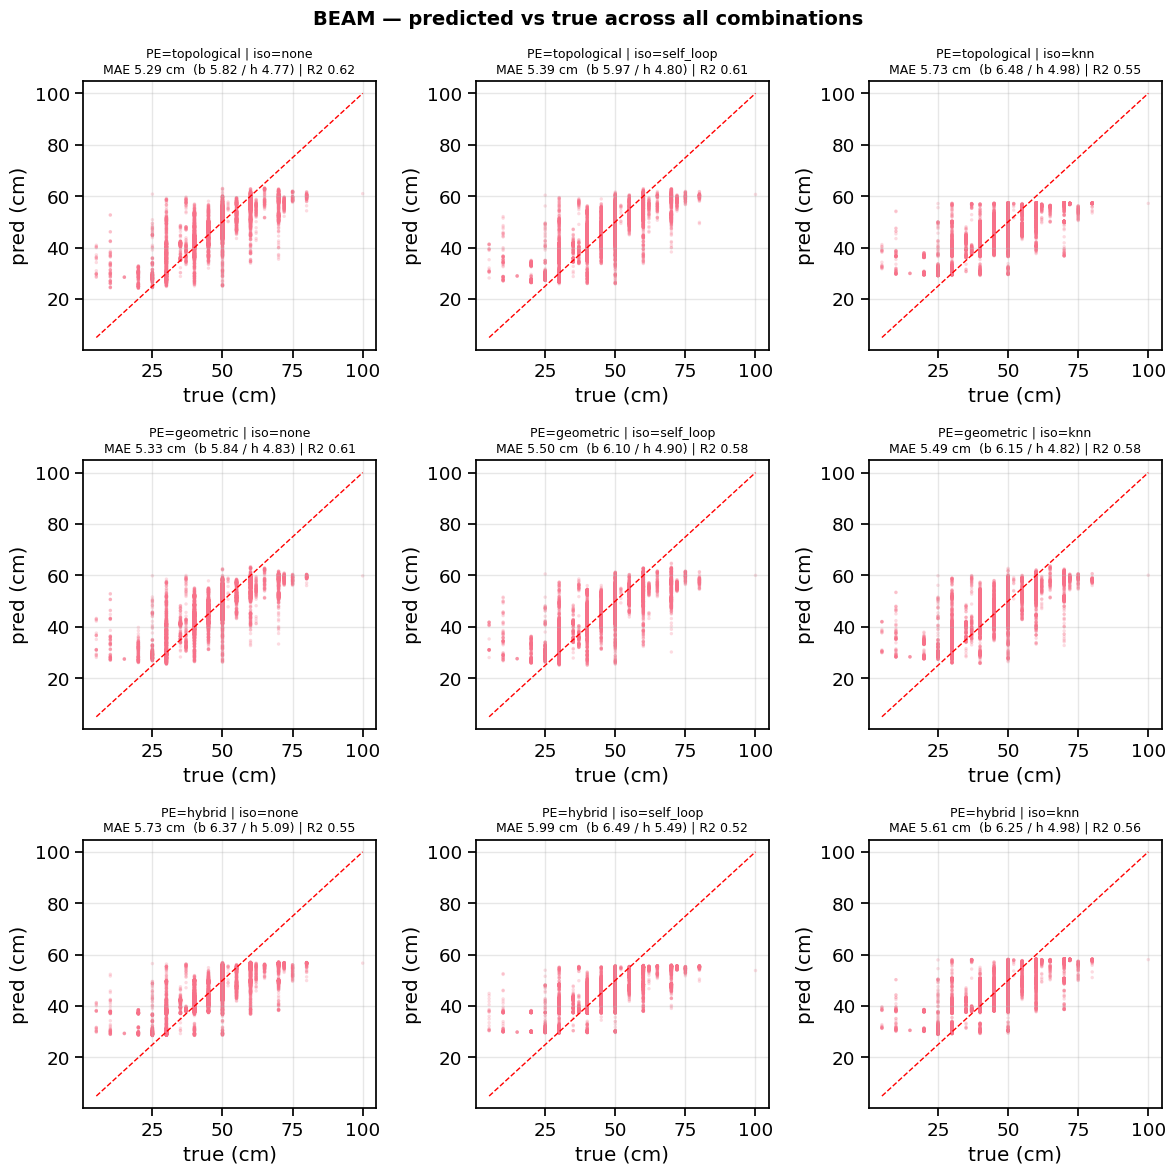

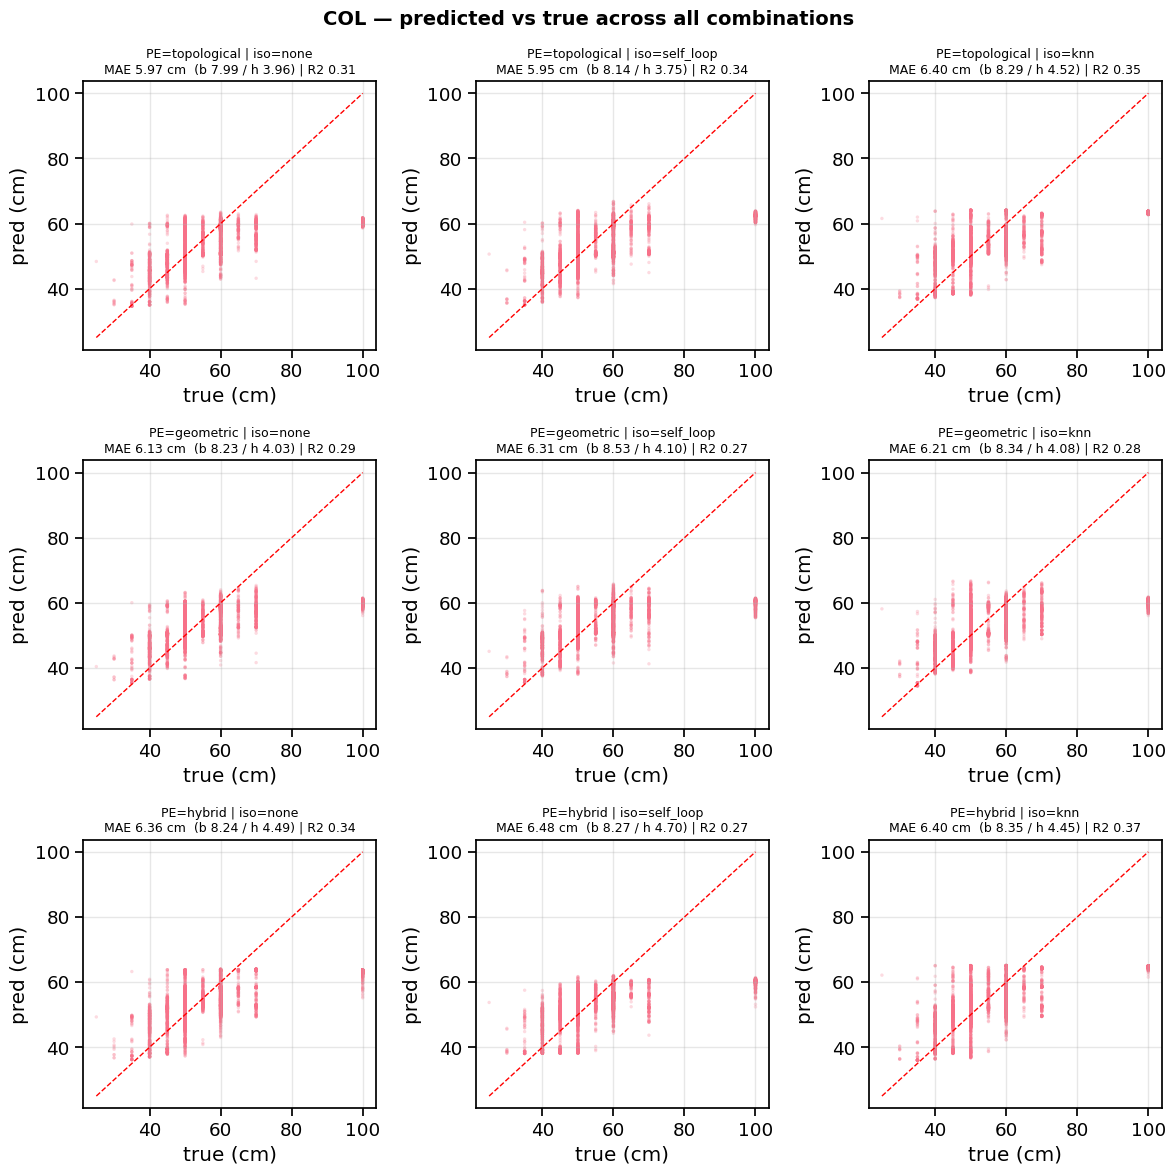

In [8]:
# ## Plot ALL combinations: predicted vs true (grid) — run after the SWEEP cell
import matplotlib.pyplot as plt
import numpy as np

def plot_combo_grid(element):           # element: "beam" or "col"
    rows, cols = pe_modes, iso_strategies
    fig, axes = plt.subplots(len(rows), len(cols),
                             figsize=(4*len(cols), 4*len(rows)), squeeze=False)
    for r, pe in enumerate(rows):
        for c, iso in enumerate(cols):
            ax = axes[r][c]; d = sweep_preds.get((pe, iso))
            if d is None or d[f"{element}_true"].shape[0] == 0:
                ax.set_visible(False); continue
            at = d[f"{element}_true"]; ap = d[f"{element}_pred"]
            mae_b = np.mean(np.abs(ap[:, 0] - at[:, 0]))   # width
            mae_h = np.mean(np.abs(ap[:, 1] - at[:, 1]))   # height
            t = at.ravel(); p = ap.ravel()
            ax.scatter(t, p, s=6, alpha=0.25, edgecolors="none")
            lo, hi = float(min(t.min(), p.min())), float(max(t.max(), p.max()))
            ax.plot([lo, hi], [lo, hi], "r--", lw=1)
            mae = np.mean(np.abs(t - p))
            ss_res = np.sum((t - p) ** 2); ss_tot = np.sum((t - t.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
            ax.set_title(f"PE={pe} | iso={iso}\nMAE {mae:.2f} cm  (b {mae_b:.2f} / h {mae_h:.2f})"
                         f" | R2 {r2:.2f}", fontsize=9)
            ax.set_xlabel("true (cm)"); ax.set_ylabel("pred (cm)"); ax.grid(alpha=0.3)
    fig.suptitle(f"{element.upper()} — predicted vs true across all combinations",
                 fontsize=14, fontweight="bold")
    fig.tight_layout(); plt.show()

plot_combo_grid("beam")
plot_combo_grid("col")


## How the metrics are computed (read me)

All metrics are in **cm** (except R²) and computed on **inverse-transformed** predictions, i.e. real units — see `trainer._eval_loop` / `trainer.evaluate` and the `_reg()` helper in the SWEEP cell.

**Per-type (`beam`, `column`)** — every node of that type is pooled across all test graphs:
- `MAE = mean(|pred − true|)` over node × {width, height}. **Width (b) and height (h) are ALSO reported separately** (`*_width_MAE`, `*_height_MAE`) so you can see which dimension is harder.
- `RMSE = √mean(err²)`. (Plain MSE is dropped — it is just RMSE² in cm², not interpretable.)
- `R²` is computed **per dimension** (each centered on its own mean) and then **uniform-averaged** across b and h — this is the sklearn `multioutput='uniform_average'` convention. Averaging per-dim R² avoids mixing the different scales/variances of b and h into one misleading ratio. `width_R2` and `height_R2` are also reported on their own.

**Overall — two flavours (the key distinction):**

| metric | how | meaning |
|---|---|---|
| **weighted_MAE** | concatenate *all* beam + column node errors, then `mean(|err|)` | each **node** counts equally → the more numerous type (beams) dominates. **This is the selection metric.** |
| **unweighted_MAE** | `mean(beam_MAE, col_MAE)` | each **type** counts equally regardless of node count |

`overall_RMSE / R2` are the **node-pooled** versions (R² = uniform avg of width/height R²).

**Baseline & generalization:**
- **`baseline_MAE`** = a naive predictor that outputs the **per-type median (b,h) of the *training* pool** for every test node (source: `g[nt].y` of the training graphs only; median is robust to outliers and lands on standard RC sizes). The HGT only earns its complexity by beating this. **`improve_vs_baseline` = baseline_MAE − weighted_MAE** (positive = model better).
- **`cv_MAE ± cv_MAE_std`** = mean and spread of the k-fold validation MAE. A combo with low mean *and* low std is trustworthy; low mean with high std is a lucky fold.

> Bug history: `evaluate()` previously overwrote `test_overall_mae` with the *unweighted* value, so the old sweep's weighted/unweighted columns were identical. Fixed — they now differ correctly. The sweep also now computes width/height MAE, per-dim R², and the median baseline directly from the saved predictions.

**Hit-rate (`pct_within_tol`, default 5 cm):** the percentage of predictions whose error is below the tolerance, i.e. `|pred − true| ≤ HIT_TOL_CM`. The `±`/tolerance is **not** an arbitrary band — it is exactly *"the prediction is off by less than 5 cm"*, counted over all b & h entries and reported as a %. MAE tells you the *average* miss; the hit-rate tells you *how often* you are inside a usable tolerance. Reported overall, per type (`beam/col_within_tol`), and per dimension (`width/height_within_tol`). Change `HIT_TOL_CM` at the top of the SWEEP cell to use a different tolerance.

**Error is reported at four granularities** (so nothing is hidden by averaging):
- **per type** — `beam_*`, `col_*` columns.
- **per label / dimension** — `width_*`, `height_*` (b vs h separately).
- **per node** — `pe_isolated_pernode_errors.csv` (one row per node: true/pred b,h, abs errors, isolation flag).
- **per graph** — `pe_isolated_persample_errors.csv` (one row per building, MAE + node count; used for the worst-graph / bug-hunting list).

---

### Train/test workflow — what gets reported vs what gets shipped

There are **two different models** and they serve different purposes:

| | trained on | used for |
|---|---|---|
| **sweep model** (`fit_final` in the sweep) | 85% train pool | **evaluated once** on the held-out 15% test split → these are your **honest, reportable test metrics** |
| **deployment model** (the new FINAL cell) | **all 254 graphs** | the model you actually ship/use for inference |

Why both: you **cannot** train on the whole dataset *and* report test metrics on that same data — the model would be graded on samples it already saw (leakage), so the numbers would be inflated and meaningless. So the correct order is:

1. Hold out the 15% test set **once**.
2. k-fold **CV on the 85%** → generalization estimate during the *training process* (`cv_MAE ± cv_MAE_std`).
3. Train `fit_final` on the 85%, **evaluate once on the 15%** → the **final test metrics** you publish.
4. **Only then** retrain on **all 254 graphs** (the FINAL deployment cell) → the model you deliver. It has *no* clean test set of its own; you report the step-3 test metrics as its expected performance (it saw strictly more data, so real performance should be ≥ those).

So yes — you train the *shipped* model on the whole dataset at the very end, but the *reported* test metrics come from step 3, **before** the test graphs were folded into training. If instead you have a **separate external** test set (not part of the 254), then you can train on all 254 from the start and evaluate on that external set directly — tell me if that's your situation.

Error-EDA for combo: topological_none
saved figure -> ../results/han/figures/error_eda_topological_none.png


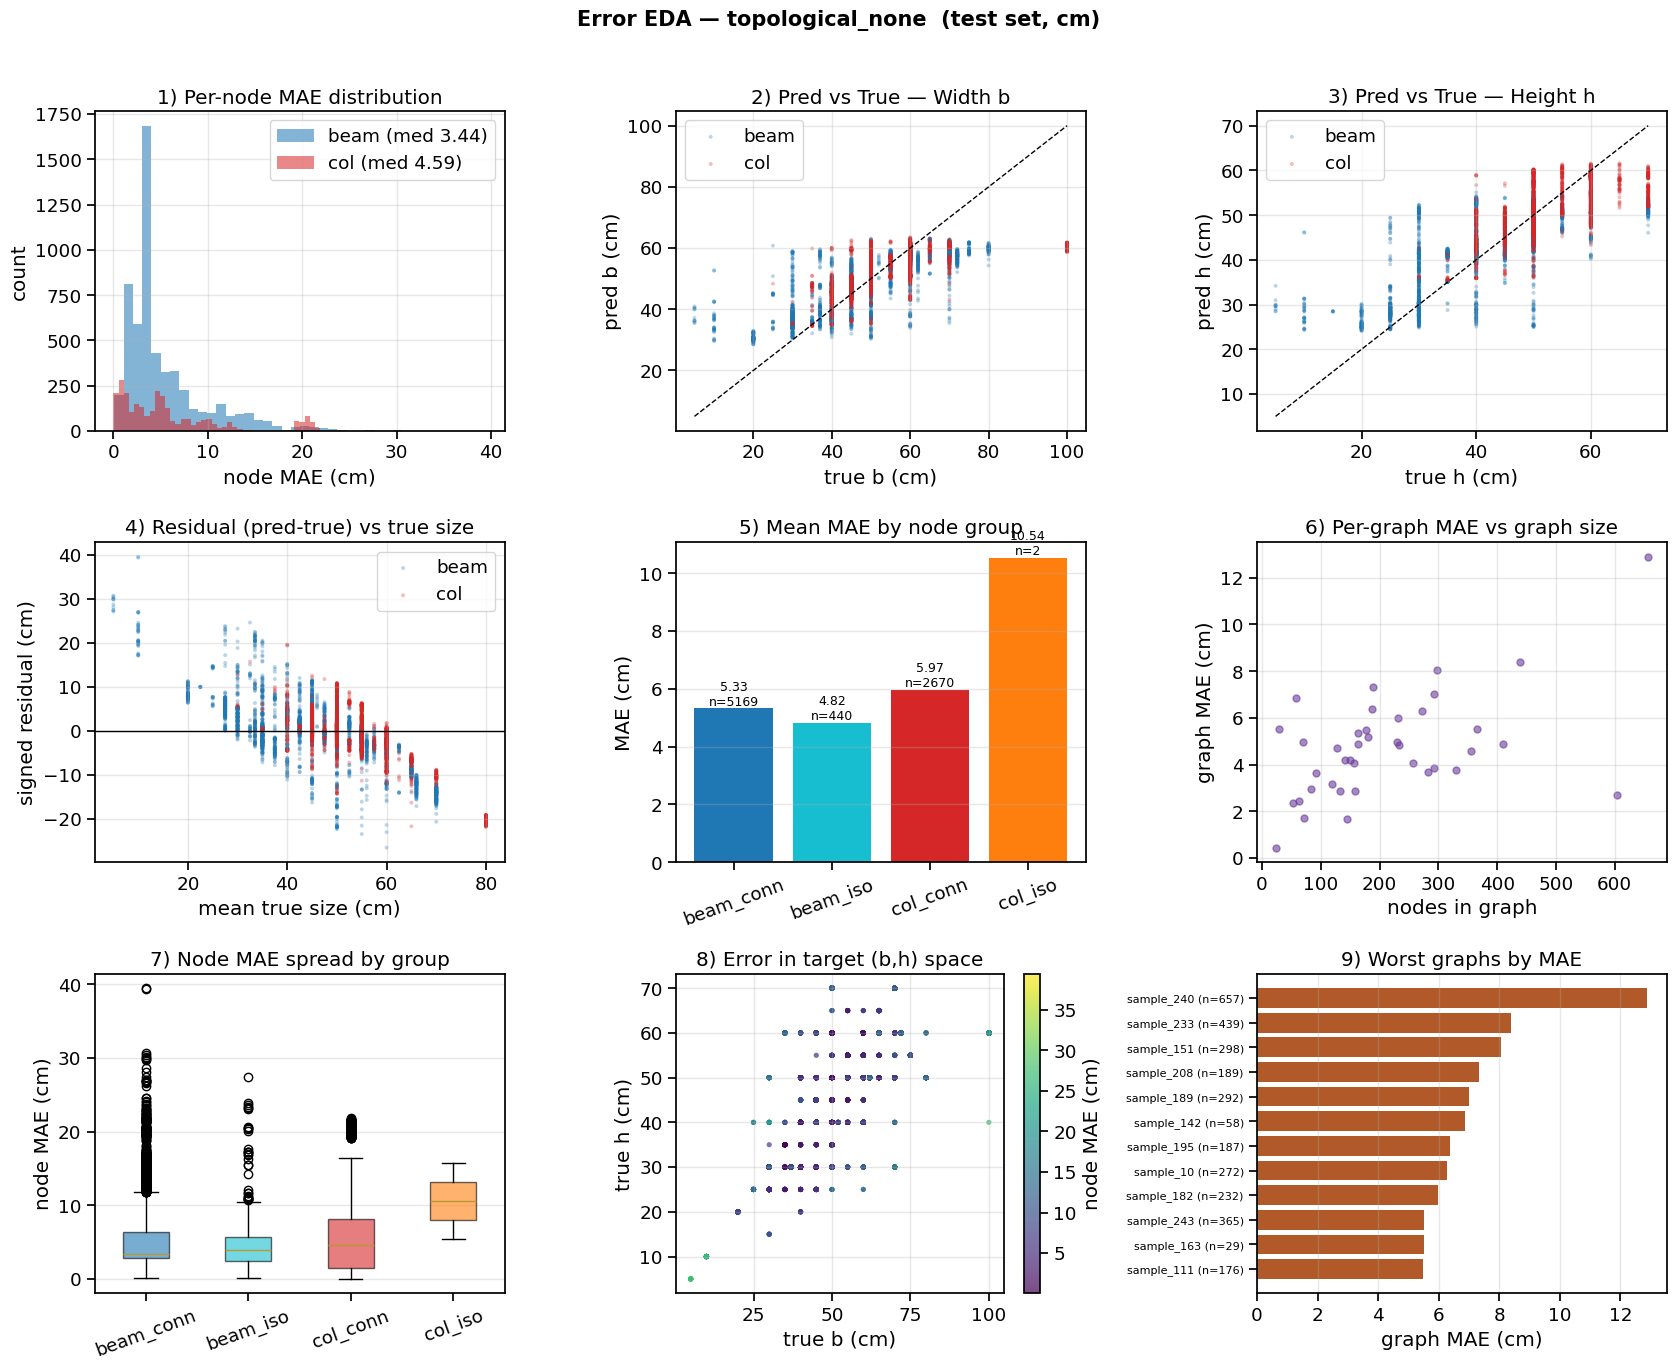

In [9]:
# ## 3x3 ERROR-EDA — understand the NATURE of the error for one model
# Uses the per-node records from the SWEEP cell. Defaults to the BEST combo
# (lowest weighted MAE); set EDA_COMBO = ("hybrid", "knn") to inspect another.
# Saves the figure to results/figures/.
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# --- load the per-node table (in-memory if the sweep just ran, else from CSV) ---
try:
    _pn = pernode_table.copy()
    _ps = persample_table.copy()
except NameError:
    _pn = pd.read_csv("../results/han/pe_isolated_pernode_errors.csv")
    _ps = pd.read_csv("../results/han/pe_isolated_persample_errors.csv")

# --- choose the combo to analyse ---
EDA_COMBO = None  # e.g. ("hybrid", "knn"); None -> best combo from the sweep
if EDA_COMBO is not None:
    combo_tag = f"{EDA_COMBO[0]}_{EDA_COMBO[1]}"
elif "best_combo" in dir() and best_combo is not None:
    combo_tag = f"{best_combo[0]}_{best_combo[1]}"
else:
    combo_tag = _pn["combo"].iloc[0]
print(f"Error-EDA for combo: {combo_tag}")

d  = _pn[_pn["combo"] == combo_tag].copy()
ps = _ps[_ps["combo"] == combo_tag].copy()
assert len(d), f"no per-node rows for combo {combo_tag}"

# label: beam/col x conn/iso  (answers 'are isolated nodes only beams?')
d["type"]  = d["node_type"].map({"beam": "beam", "column": "col"}).fillna(d["node_type"])
d["group"] = d["type"] + np.where(d["was_isolated"], "_iso", "_conn")
d["true_size"] = (d["true_b"] + d["true_h"]) / 2.0
d["resid"]     = ((d["pred_b"] - d["true_b"]) + (d["pred_h"] - d["true_h"])) / 2.0  # signed bias

GROUPS = ["beam_conn", "beam_iso", "col_conn", "col_iso"]
GCOL   = {"beam_conn": "#1f77b4", "beam_iso": "#17becf",
          "col_conn": "#d62728", "col_iso": "#ff7f0e"}

fig, ax = plt.subplots(3, 3, figsize=(17, 14))
fig.suptitle(f"Error EDA — {combo_tag}  (test set, cm)", fontsize=15, fontweight="bold")

# 1) per-node MAE distribution, beam vs col
a = ax[0, 0]
for t, c in [("beam", "#1f77b4"), ("col", "#d62728")]:
    v = d.loc[d["type"] == t, "node_mae"]
    if len(v):
        a.hist(v, bins=40, alpha=0.55, label=f"{t} (med {v.median():.2f})", color=c)
a.set_title("1) Per-node MAE distribution"); a.set_xlabel("node MAE (cm)")
a.set_ylabel("count"); a.legend(); a.grid(alpha=0.3)

# 2) predicted vs true — WIDTH (b)
a = ax[0, 1]
for t, c in [("beam", "#1f77b4"), ("col", "#d62728")]:
    s = d[d["type"] == t]
    a.scatter(s["true_b"], s["pred_b"], s=8, alpha=0.3, color=c, label=t, edgecolors="none")
lo, hi = d[["true_b", "pred_b"]].min().min(), d[["true_b", "pred_b"]].max().max()
a.plot([lo, hi], [lo, hi], "k--", lw=1)
a.set_title("2) Pred vs True — Width b"); a.set_xlabel("true b (cm)")
a.set_ylabel("pred b (cm)"); a.legend(); a.grid(alpha=0.3)

# 3) predicted vs true — HEIGHT (h)
a = ax[0, 2]
for t, c in [("beam", "#1f77b4"), ("col", "#d62728")]:
    s = d[d["type"] == t]
    a.scatter(s["true_h"], s["pred_h"], s=8, alpha=0.3, color=c, label=t, edgecolors="none")
lo, hi = d[["true_h", "pred_h"]].min().min(), d[["true_h", "pred_h"]].max().max()
a.plot([lo, hi], [lo, hi], "k--", lw=1)
a.set_title("3) Pred vs True — Height h"); a.set_xlabel("true h (cm)")
a.set_ylabel("pred h (cm)"); a.legend(); a.grid(alpha=0.3)

# 4) signed residual vs true size — bias & heteroscedasticity
a = ax[1, 0]
for t, c in [("beam", "#1f77b4"), ("col", "#d62728")]:
    s = d[d["type"] == t]
    a.scatter(s["true_size"], s["resid"], s=8, alpha=0.3, color=c, label=t, edgecolors="none")
a.axhline(0, color="k", lw=1)
a.set_title("4) Residual (pred-true) vs true size"); a.set_xlabel("mean true size (cm)")
a.set_ylabel("signed residual (cm)"); a.legend(); a.grid(alpha=0.3)

# 5) mean MAE by node group (beam/col x conn/iso) with counts
a = ax[1, 1]
gm = d.groupby("group")["node_mae"].agg(["mean", "size"]).reindex(GROUPS)
bars = a.bar(range(len(GROUPS)), gm["mean"].values,
             color=[GCOL[g] for g in GROUPS])
for i, (m_, n_) in enumerate(zip(gm["mean"].values, gm["size"].values)):
    if np.isfinite(m_):
        a.text(i, m_, f"{m_:.2f}\nn={int(n_)}", ha="center", va="bottom", fontsize=9)
a.set_xticks(range(len(GROUPS))); a.set_xticklabels(GROUPS, rotation=20)
a.set_title("5) Mean MAE by node group"); a.set_ylabel("MAE (cm)"); a.grid(alpha=0.3, axis="y")

# 6) per-graph MAE vs graph size — do big/small buildings fail?
a = ax[1, 2]
if len(ps):
    a.scatter(ps["n_nodes"], ps["MAE"], s=25, alpha=0.6, color="#6a3d9a")
    a.set_title("6) Per-graph MAE vs graph size"); a.set_xlabel("nodes in graph")
    a.set_ylabel("graph MAE (cm)"); a.grid(alpha=0.3)
else:
    a.set_visible(False)

# 7) boxplot of node MAE by group
a = ax[2, 0]
data_box = [d.loc[d["group"] == g, "node_mae"].values for g in GROUPS]
data_box = [(x if len(x) else [np.nan]) for x in data_box]
bp = a.boxplot(data_box, labels=GROUPS, showfliers=True, patch_artist=True)
for patch, g in zip(bp["boxes"], GROUPS):
    patch.set_facecolor(GCOL[g]); patch.set_alpha(0.6)
a.set_xticklabels(GROUPS, rotation=20)
a.set_title("7) Node MAE spread by group"); a.set_ylabel("node MAE (cm)"); a.grid(alpha=0.3, axis="y")

# 8) target-space error heat — WHERE in (b,h) space are errors?
a = ax[2, 1]
sc = a.scatter(d["true_b"], d["true_h"], c=d["node_mae"], s=14,
               cmap="viridis", alpha=0.7, edgecolors="none")
fig.colorbar(sc, ax=a, label="node MAE (cm)")
a.set_title("8) Error in target (b,h) space"); a.set_xlabel("true b (cm)")
a.set_ylabel("true h (cm)"); a.grid(alpha=0.3)

# 9) worst graphs by MAE (data-bug hunting)
a = ax[2, 2]
if len(ps):
    top = ps.sort_values("MAE", ascending=False).head(12).iloc[::-1]
    a.barh(range(len(top)), top["MAE"].values, color="#b15928")
    a.set_yticks(range(len(top)))
    a.set_yticklabels([f"{s[:22]} (n={n})" for s, n in zip(top["sample"], top["n_nodes"])],
                      fontsize=8)
    a.set_title("9) Worst graphs by MAE"); a.set_xlabel("graph MAE (cm)"); a.grid(alpha=0.3, axis="x")
else:
    a.set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.97])
os.makedirs("../results/han/figures", exist_ok=True)
out_png = f"../results/han/figures/error_eda_{combo_tag}.png"
fig.savefig(out_png, dpi=130, bbox_inches="tight")
print(f"saved figure -> {out_png}")
plt.show()


In [10]:
# ## EXTERNAL TEST EVALUATION — full metrics on data/test (real held-out set)
# Evaluates the FINAL DEPLOYMENT model (trained on ALL train graphs) on the
# SEPARATE external test set built by notebook 3 (data/graphs/test_graphs.pt).
# Reports the SAME suite as the sweep: MAE (weighted + unweighted), per type,
# per dimension (b/h), RMSE, R2 (per-dim uniform avg), hit-rate (<= HIT_TOL_CM),
# the median baseline, per-NODE + per-GRAPH errors, the beam/col x conn/iso
# breakdown, and the worst graphs. Saves results/test_*.csv + test_metrics.json.
# Run AFTER the sweep + the FINAL DEPLOYMENT MODEL cell.
import os, copy, json
import numpy as np, pandas as pd, torch
from src.data_manager.data_processor import (PositionalEncoder, IsolatedNodeHandler,
                                             FeatureNormalizer, TargetNormalizer)
from src.models import build_model
from src.training.trainer import Trainer

TEST_PT, TRAIN_PT = "../data/graphs/test_graphs.pt", "../data/graphs/train_graphs.pt"
MODELS_DIR = globals().get("MODELS_DIR", "../results/han/models")
HIT_TOL_CM = float(globals().get("HIT_TOL_CM", 5.0))
knn_k  = config["data"]["isolated"].get("knn_k", 4)
pe_dim = config["data"]["pe"].get("dim", 8)

# --- resolve the winning combo (in-memory, else from saved summary) ---
if globals().get("best_combo") is not None:
    best_pe, best_iso = best_combo
else:
    with open("../results/han/best_model_summary.json") as f:
        b = json.load(f)["best"]
    best_pe, best_iso = b["PE"], b["isolated"]
FULL_DIR = f"{MODELS_DIR}/{best_pe}_{best_iso}_FULL"
print(f"Deployment model = {best_pe}_{best_iso}_FULL  ->  external test eval")

# --- load + transform the external test graphs exactly like training ---
_loaded = torch.load(TEST_PT, weights_only=False)
istup = isinstance(_loaded[0], tuple)
test_t = [g for (_, g) in _loaded] if istup else list(_loaded)
if istup:
    for nm, g in _loaded:
        if not hasattr(g, "sample_name"): g.sample_name = nm
IsolatedNodeHandler(strategy=best_iso, k=knn_k).transform(test_t)   # tags was_isolated
PositionalEncoder(mode=best_pe, dim=pe_dim).transform(test_t)
print(f"Loaded {len(test_t)} test graphs")

def _make_model():
    # model is chosen by config["model"]["type"] (== "han" here)
    # through the shared factory, so HGT and HAN wire up identically.
    return build_model(config)

# --- ready Trainer: reuse in-memory tr_full if present, else load from disk ---
if isinstance(globals().get("tr_full"), Trainer):
    tr = tr_full
    print("Using in-memory deployment trainer (tr_full).")
else:
    cfg = copy.deepcopy(config); cfg["paths"] = {"checkpoints": FULL_DIR}
    tr = Trainer(model=_make_model(), config=cfg)
    with torch.no_grad():                          # lazy-init model, then load weights
        tr.model(test_t[0].clone().to(tr.device))
    tr.model.to(tr.device)
    ckpt = torch.load(f"{FULL_DIR}/final_best.pt", map_location=tr.device, weights_only=False)
    tr.model.load_state_dict(ckpt["model_state_dict"])
    tr.feature_normalizer = FeatureNormalizer.load(f"{FULL_DIR}/feature_normalizer.pkl")
    tr.target_normalizer  = TargetNormalizer.load(f"{FULL_DIR}/target_normalizer.pkl")
    print(f"Loaded deployment model + scalers from {FULL_DIR}")

# --- evaluate (metrics already inverse-transformed to real cm) ---
out = tr.evaluate(test_t)

def _reg(true, pred, tol=HIT_TOL_CM):
    keys = ["mae","rmse","width_mae","height_mae","width_r2","height_r2","r2",
            "within_tol","width_within_tol","height_within_tol"]
    if true.shape[0] == 0:
        return {k: float("nan") for k in keys}
    err = pred - true
    r = {"mae": float(np.abs(err).mean()), "rmse": float(np.sqrt((err**2).mean())),
         "within_tol": float((np.abs(err) <= tol).mean())}
    for di, nm in enumerate(["width", "height"]):
        e = err[:, di]; y = true[:, di]
        r[f"{nm}_mae"] = float(np.abs(e).mean())
        r[f"{nm}_within_tol"] = float((np.abs(e) <= tol).mean())
        ss_res = float((e**2).sum()); ss_tot = float(((y - y.mean())**2).sum())
        r[f"{nm}_r2"] = (1 - ss_res/ss_tot) if ss_tot > 0 else float("nan")
    r["r2"] = float(np.nanmean([r["width_r2"], r["height_r2"]]))
    return r

groups = {"beam_conn": [], "beam_iso": [], "col_conn": [], "col_iso": []}
bt, bp, ct, cp = [], [], [], []; persample = []; pernode_rows = []
for g, pred in zip(test_t, out["predictions"]):
    name = getattr(g, "sample_name", "graph"); gerrs = []
    for nt, tt, pp, gc, gi in [("beam", bt, bp, "beam_conn", "beam_iso"),
                               ("column", ct, cp, "col_conn", "col_iso")]:
        if nt not in pred or not hasattr(g[nt], "y"): continue
        true = g[nt].y.cpu().numpy(); P = pred[nt]
        tt.append(true); pp.append(P)
        err = np.abs(P - true).mean(axis=1); gerrs.append(err)
        wasiso = getattr(g[nt], "was_isolated", None)
        wi = (wasiso.cpu().numpy().astype(bool) if wasiso is not None
              else np.zeros(true.shape[0], dtype=bool))
        groups[gi].append(err[wi]); groups[gc].append(err[~wi])
        for j in range(true.shape[0]):
            pernode_rows.append({"sample": name, "node_type": nt, "node_idx": j,
                "was_isolated": bool(wi[j]),
                "true_b": float(true[j,0]), "true_h": float(true[j,1]),
                "pred_b": float(P[j,0]),    "pred_h": float(P[j,1]),
                "abs_err_b": float(abs(P[j,0]-true[j,0])),
                "abs_err_h": float(abs(P[j,1]-true[j,1])),
                "node_mae": float(err[j])})
    if gerrs:
        a = np.concatenate(gerrs); persample.append((name, int(a.size), float(a.mean())))

BT = np.concatenate(bt) if bt else np.empty((0,2)); BP = np.concatenate(bp) if bp else np.empty((0,2))
CT = np.concatenate(ct) if ct else np.empty((0,2)); CP = np.concatenate(cp) if cp else np.empty((0,2))
beam_r, col_r = _reg(BT, BP), _reg(CT, CP)
allT = np.concatenate([x for x in (BT, CT) if x.shape[0]]) if (bt or ct) else np.empty((0,2))
allP = np.concatenate([x for x in (BP, CP) if x.shape[0]]) if (bp or cp) else np.empty((0,2))
over_r = _reg(allT, allP)

# baseline = per-type median (b,h) of the TRAIN targets (same bar as the sweep)
_tr = torch.load(TRAIN_PT, weights_only=False)
_trg = [g for (_, g) in _tr] if isinstance(_tr[0], tuple) else list(_tr)
base_pred = {}
for nt in ("beam", "column"):
    ys = [g[nt].y.cpu().numpy() for g in _trg
          if nt in g.node_types and hasattr(g[nt], "y") and g[nt].y is not None]
    if ys: base_pred[nt] = np.median(np.concatenate(ys), axis=0)
base_err, base_type = [], {}
for nt, TT in (("beam", BT), ("column", CT)):
    if nt in base_pred and TT.shape[0]:
        e = np.abs(base_pred[nt] - TT).mean(axis=1); base_type[nt] = float(e.mean()); base_err.append(e)
base_w = float(np.concatenate(base_err).mean()) if base_err else float("nan")

def gstat(k):
    a = [x for x in groups[k] if len(x)]
    if not a: return (float("nan"), 0)
    v = np.concatenate(a); return (float(v.mean()), int(v.size))

tol = int(HIT_TOL_CM)
row = {
 "weighted_MAE": round(over_r["mae"], 3),
 "unweighted_MAE": round((beam_r["mae"] + col_r["mae"]) / 2, 3),
 "beam_MAE": round(beam_r["mae"], 3), "col_MAE": round(col_r["mae"], 3),
 "width_MAE": round(over_r["width_mae"], 3), "height_MAE": round(over_r["height_mae"], 3),
 "beam_width_MAE": round(beam_r["width_mae"], 3), "beam_height_MAE": round(beam_r["height_mae"], 3),
 "col_width_MAE": round(col_r["width_mae"], 3), "col_height_MAE": round(col_r["height_mae"], 3),
 "overall_RMSE": round(over_r["rmse"], 3), "beam_RMSE": round(beam_r["rmse"], 3), "col_RMSE": round(col_r["rmse"], 3),
 "overall_R2": round(over_r["r2"], 3), "width_R2": round(over_r["width_r2"], 3), "height_R2": round(over_r["height_r2"], 3),
 "beam_R2": round(beam_r["r2"], 3), "col_R2": round(col_r["r2"], 3),
 f"pct_within_{tol}cm": round(100*over_r["within_tol"], 1),
 "beam_within": round(100*beam_r["within_tol"], 1), "col_within": round(100*col_r["within_tol"], 1),
 "width_within": round(100*over_r["width_within_tol"], 1), "height_within": round(100*over_r["height_within_tol"], 1),
 "baseline_MAE": round(base_w, 3), "improve_vs_baseline": round(base_w - over_r["mae"], 3),
}
test_metrics = pd.DataFrame([row]).T.rename(columns={0: "value"})

os.makedirs("../results/han", exist_ok=True)
pd.DataFrame(pernode_rows).to_csv("../results/han/test_pernode_errors.csv", index=False)
(pd.DataFrame([{"sample": n, "n_nodes": k, "MAE": round(e, 3)} for n, k, e in persample])
   .sort_values("MAE", ascending=False)
   .to_csv("../results/han/test_persample_errors.csv", index=False))
bd = {}
for k in ["beam_conn", "beam_iso", "col_conn", "col_iso"]:
    mae_, n_ = gstat(k); bd[f"{k}_MAE"] = round(mae_, 3); bd[f"{k}_n"] = n_
pd.DataFrame([bd]).to_csv("../results/han/test_error_breakdown.csv", index=False)
test_metrics.to_csv("../results/han/test_metrics.csv")
with open("../results/han/test_metrics.json", "w") as f:
    json.dump(row, f, indent=2, default=float)

print("\n" + "=" * 60)
print(f"EXTERNAL TEST METRICS  ({len(test_t)} graphs, real cm)")
print("=" * 60)
print(test_metrics.to_string())
print("\nGroup breakdown (beam/col x conn/iso):")
print(pd.DataFrame([bd]).to_string(index=False))
print(f"\nbaseline (train median b,h): "
      + ", ".join(f"{k}={np.round(v,1).tolist()}" for k, v in base_pred.items()))
print("\nWorst test graphs by MAE:")
for n, k, e in sorted(persample, key=lambda x: -x[2])[:8]:
    print(f"  {n}: {e:.2f} (n={k})")
print(f"\n>>> TEST weighted MAE {row['weighted_MAE']} cm | unweighted {row['unweighted_MAE']} "
      f"| within {tol}cm {row[f'pct_within_{tol}cm']}% | beats baseline by {row['improve_vs_baseline']} cm")
print("saved: results/test_metrics.csv/json, test_pernode_errors.csv, "
      "test_persample_errors.csv, test_error_breakdown.csv")
test_metrics


07:42:18 | TRAINER  | INFO     | 
Evaluating on 59 graphs


Deployment model = topological_none_FULL  ->  external test eval
Loaded 59 test graphs
Using in-memory deployment trainer (tr_full).


07:42:19 | TRAINER  | INFO     | 
Test results (real units):
07:42:19 | TRAINER  | INFO     |   test_beam_mae               : 5.5726
07:42:19 | TRAINER  | INFO     |   test_beam_mse               : 57.3031
07:42:19 | TRAINER  | INFO     |   test_beam_rmse              : 7.5699
07:42:19 | TRAINER  | INFO     |   test_beam_width_mae         : 5.8088
07:42:19 | TRAINER  | INFO     |   test_beam_height_mae        : 5.3364
07:42:19 | TRAINER  | INFO     |   test_beam_r2                : 0.5362
07:42:19 | TRAINER  | INFO     |   test_column_mae             : 3.8877
07:42:19 | TRAINER  | INFO     |   test_column_mse             : 29.6078
07:42:19 | TRAINER  | INFO     |   test_column_rmse            : 5.4413
07:42:19 | TRAINER  | INFO     |   test_column_width_mae       : 4.3934
07:42:19 | TRAINER  | INFO     |   test_column_height_mae      : 3.3819
07:42:19 | TRAINER  | INFO     |   test_column_r2              : 0.4831
07:42:19 | TRAINER  | INFO     |   test_overall_mae            : 5.0369
0


EXTERNAL TEST METRICS  (59 graphs, real cm)
                      value
weighted_MAE         5.0370
unweighted_MAE       4.7300
beam_MAE             5.5730
col_MAE              3.8880
width_MAE            5.3590
height_MAE           4.7150
beam_width_MAE       5.8090
beam_height_MAE      5.3360
col_width_MAE        4.3930
col_height_MAE       3.3820
overall_RMSE         6.9640
beam_RMSE            7.5700
col_RMSE             5.4410
overall_R2           0.5880
width_R2             0.5490
height_R2            0.6280
beam_R2              0.5360
col_R2               0.4770
pct_within_5cm      62.0000
beam_within         58.5000
col_within          69.6000
width_within        59.3000
height_within       64.7000
baseline_MAE         7.3440
improve_vs_baseline  2.3070

Group breakdown (beam/col x conn/iso):
 beam_conn_MAE  beam_conn_n  beam_iso_MAE  beam_iso_n  col_conn_MAE  col_conn_n  col_iso_MAE  col_iso_n
        5.5810         8525        5.4950         930        3.8880        4407    

,value
weighted_MAE,5.0370
unweighted_MAE,4.7300
beam_MAE,5.5730
col_MAE,3.8880
width_MAE,5.3590
...,...
col_within,69.6000
width_within,59.3000
height_within,64.7000
baseline_MAE,7.3440
